Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=44.894, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=46.797, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=46.781, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=43.355, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.612 seconds

=== Optimal ARIMA Order ===
Selected (p,d,q): (0, 1, 0)


C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


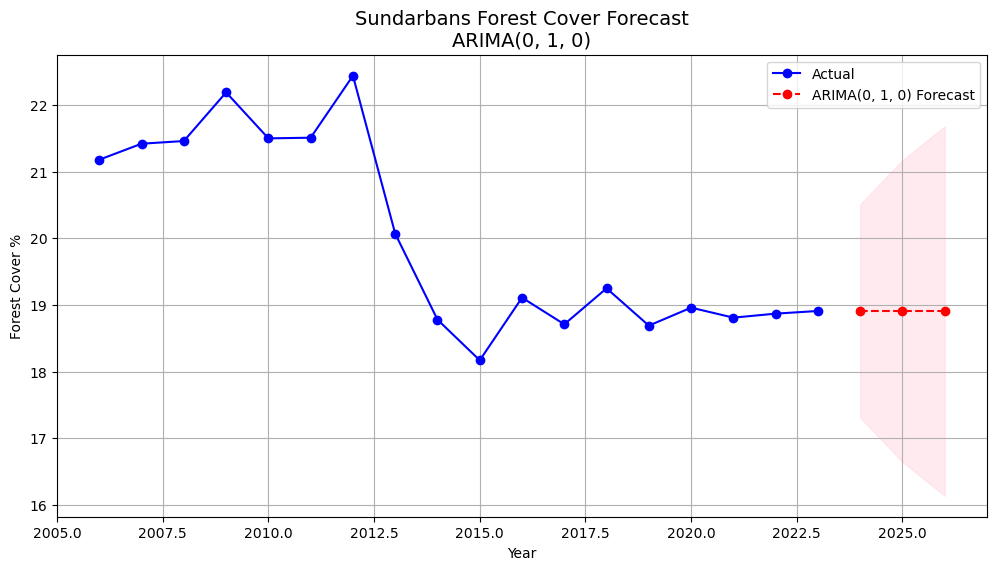


=== Forecast ===
2024: 18.91% (95% CI: 17.31% - 20.51%)
2025: 18.91% (95% CI: 16.65% - 21.17%)
2026: 18.91% (95% CI: 16.14% - 21.68%)


In [1]:
import pandas as pd
from pmdarima import auto_arima
import matplotlib.pyplot as plt

years = [
    '2006', '2007', '2008', '2009', '2010', '2011', '2012',
    '2013', '2014', '2015', '2016', '2017', '2018',
    '2019', '2020', '2021', '2022', '2023'
]

non_forest_percentages = [
    78.82, 78.58, 78.54, 77.81, 78.50, 78.49, 77.56,
    79.93, 81.22, 81.83, 80.89, 81.29, 80.75,
    81.31, 81.04, 81.19, 81.13, 81.09
]

remaining_forest_percentages = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91
]

# Prepare data
years = [int(year) for year in years]
forest_series = pd.Series(remaining_forest_percentages, index=years)

# Run AutoARIMA with detailed search
model = auto_arima(forest_series,
                  seasonal=False,
                  suppress_warnings=True,
                  stepwise=True,
                  trace=True,  # Show model selection process
                  error_action='ignore',
                  information_criterion='aic')

print("\n=== Optimal ARIMA Order ===")
print(f"Selected (p,d,q): {model.order}")

# Forecast next 3 years
forecast, conf_int = model.predict(n_periods=3, return_conf_int=True)
forecast_years = [2024, 2025, 2026]

# Plot results
plt.figure(figsize=(12,6))
plt.plot(forest_series.index, forest_series, 'bo-', label='Actual')
plt.plot(forecast_years, forecast, 'ro--', label=f'ARIMA{model.order} Forecast')
plt.fill_between(forecast_years, conf_int[:,0], conf_int[:,1], color='pink', alpha=0.3)
plt.title(f"Sundarbans Forest Cover Forecast\nARIMA{model.order}", fontsize=14)
plt.xlabel('Year')
plt.ylabel('Forest Cover %')
plt.legend()
plt.grid(True)
plt.show()

print("\n=== Forecast ===")
for year, val, (lower, upper) in zip(forecast_years, forecast, conf_int):
    print(f"{year}: {val:.2f}% (95% CI: {lower:.2f}% - {upper:.2f}%)")

In [3]:
import pandas as pd
from pmdarima import auto_arima
import matplotlib.pyplot as plt
print(pmdarima.__version__)

NameError: name 'pmdarima' is not defined